### Full Implementation

### Imports & Configs

In [1]:
import numpy as np
from tqdm import tqdm 
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib import cm 

import operator
from functools import reduce
from functools import partial
from collections import OrderedDict

import time 
from timeit import default_timer
from tqdm import tqdm 

torch.manual_seed(0)
np.random.seed(0)

In [2]:
configuration = {"Case": 'Multi-Blobs',
                 "Field": 'rho, Phi, T',
                 "Field_Mixing": 'Channel',
                 "Type": '2D Time',
                 "Epochs": 500,
                 "Batch Size": 10,
                 "Optimizer": 'Adam',
                 "Learning Rate": 0.005,
                 "Scheduler Step": 100,
                 "Scheduler Gamma": 0.5,
                 "Activation": 'GELU',
                 "Normalisation Strategy": 'Min-Max. Different',
                 "Instance Norm": 'No',
                 "Log Normalisation":  'No',
                 "Physics Normalisation": 'Yes',
                 "T_in": 200,    
                 "T_out": 200,
                 "Step": 5,
                 "Modes": 16,
                 "Width_time":32, #FNO
                 "Width_vars": 0, #U-Net
                 "Variables":3, 
                 "Noise":0.0, 
                 "Loss Function": 'LP Loss',
                 "Spatial Resolution": 1,
                 "Temporal Resolution": 1,
                 "Gradient Clipping Norm": None, 
                #  "UQ": 'Dropout',
                #  "Dropout Rate": 0.9
                 }
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Normalization Functions

In [3]:
# normalization, pointwise gaussian
class UnitGaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(UnitGaussianNormalizer, self).__init__()

        # x could be in shape of ntrain*n or ntrain*T*n or ntrain*n*T
        self.mean = torch.mean(x, 0)
        self.std = torch.std(x, 0)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        if sample_idx is None:
            std = self.std + self.eps # n
            mean = self.mean
        else:
            if len(self.mean.shape) == len(sample_idx[0].shape):
                std = self.std[sample_idx] + self.eps  # batch*n
                mean = self.mean[sample_idx]
            if len(self.mean.shape) > len(sample_idx[0].shape):
                std = self.std[:,sample_idx]+ self.eps # T*batch*n
                mean = self.mean[:,sample_idx]

        # x is in shape of batch*n or T*batch*n
        x = (x * std) + mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()

# normalization, Gaussian
class GaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(GaussianNormalizer, self).__init__()

        self.mean = torch.mean(x)
        self.std = torch.std(x)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        x = (x * (self.std + self.eps)) + self.mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()


# normalization, scaling by range
class RangeNormalizer(object):
    def __init__(self, x, low=-1.0, high=1.0):
        super(RangeNormalizer, self).__init__()
        mymin = torch.min(x, 0)[0].view(-1)
        mymax = torch.max(x, 0)[0].view(-1)

        self.a = (high - low)/(mymax - mymin)
        self.b = -self.a*mymax + high

    def encode(self, x):
        s = x.size()
        x = x.reshape(s[0], -1)
        x = self.a*x + self.b
        x = x.view(s)
        return x

    def decode(self, x):
        s = x.size()
        x = x.reshape(s[0], -1)
        x = (x - self.b)/self.a
        x = x.view(s)
        return x


    def cuda(self):
        self.a = self.a.cuda()
        self.b = self.b.cuda()

    def cpu(self):
        self.a = self.a.cpu()
        self.b = self.b.cpu()

#normalization, rangewise but single value. 
class MinMax_Normalizer(object):
    def __init__(self, x, low=0.0, high=1.0):
        super(MinMax_Normalizer, self).__init__()
        min_u = torch.min(x[:,0,:,:,:])
        max_u = torch.max(x[:,0,:,:,:])

        self.a_u = (high - low)/(max_u - min_u)
        self.b_u = -self.a_u*max_u + high

        min_v = torch.min(x[:,1,:,:,:])
        max_v = torch.max(x[:,1,:,:,:])

        self.a_v = (high - low)/(max_v - min_v)
        self.b_v = -self.a_v*max_v + high

        min_p = torch.min(x[:,2,:,:,:])
        max_p = torch.max(x[:,2,:,:,:])

        self.a_p = (high - low)/(max_p - min_p)
        self.b_p = -self.a_p*max_p + high
        

    def encode(self, x):
        s = x.size()

        u = x[:,0,:,:,:]
        u = self.a_u*u + self.b_u

        v = x[:,1,:,:,:]
        v = self.a_v*v + self.b_v

        p = x[:,2,:,:,:]
        p = self.a_p*p + self.b_p
        
        x = torch.stack((u,v,p), dim=1)

        return x

    def decode(self, x):
        s = x.size()

        u = x[:,0,:,:,:]
        u = (u - self.b_u)/self.a_u
        
        v = x[:,1,:,:,:]
        v = (v - self.b_v)/self.a_v

        p = x[:,2,:,:,:]
        p = (p - self.b_p)/self.a_p


        x = torch.stack((u,v,p), dim=1)

        return x

    def cuda(self):
        self.a_u = self.a_u.cuda()
        self.b_u = self.b_u.cuda()
        
        self.a_v = self.a_v.cuda()
        self.b_v = self.b_v.cuda() 

        self.a_p = self.a_p.cuda()
        self.b_p = self.b_p.cuda()


    def cpu(self):
        self.a_u = self.a_u.cpu()
        self.b_u = self.b_u.cpu()
        
        self.a_v = self.a_v.cpu()
        self.b_v = self.b_v.cpu()

        self.a_p = self.a_p.cpu()
        self.b_p = self.b_p.cpu()

# %%

### Loss Functions

In [4]:
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)

        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]
        # print(x.shape, y.shape)

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)

        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


### Model

In [5]:
#Extracting the configuration settings
modes = configuration['Modes']
width_time = configuration['Width_time']
width_vars = configuration['Width_vars']
output_size = configuration['Step']

batch_size = configuration['Batch Size']

batch_size2 = batch_size

t1 = default_timer()

T_in = configuration['T_in']
T = configuration['T_out']
step = configuration['Step']
num_vars = configuration['Variables']

# %%
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# %%

class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.gelu(x)
        x = self.mlp2(x)
        return x

# %%
################################################################
# fourier layer
################################################################
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, num_vars, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, num_vars, self.modes1, self.modes2, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bivxy,iovxy->bovxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes 
        out_ft = torch.zeros(batchsize, self.out_channels, num_vars,  x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :, -self.modes1:, :self.modes2], self.weights2)

        #Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(FNO2d, self).__init__()


        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width

        self.conv = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w = nn.Conv3d(self.width, self.width, 1)
    
    
    def forward(self, x):

        x1 = self.conv(x)
        x2 = self.w(x)
        x = x1+x2
        x = F.gelu(x)
        return x 


# %%

class FNO_multi(nn.Module):
    def __init__(self, modes1, modes2, width_vars, width_time):
        super(FNO_multi, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the previous T_in timesteps + 2 locations (u(t-T_in, x, y), ..., u(t-1, x, y),  x, y)
        input shape: (batchsize, x=x_discretistion, y=y_discretisation, c=T_in)
        output: the solution of the next timestep
        output shape: (batchsize, x=x_discretisation, y=y_discretisatiob, c=step)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width_vars = width_vars
        self.width_time = width_time

        self.fc0_time  = nn.Linear(T_in+2, self.width_time)

        # self.padding = 8 # pad the domain if input is non-periodic

        self.f0 = FNO2d(self.modes1, self.modes2, self.width_time)
        self.f1 = FNO2d(self.modes1, self.modes2, self.width_time)
        self.f2 = FNO2d(self.modes1, self.modes2, self.width_time)
        self.f3 = FNO2d(self.modes1, self.modes2, self.width_time)
        self.f4 = FNO2d(self.modes1, self.modes2, self.width_time)
        self.f5 = FNO2d(self.modes1, self.modes2, self.width_time)

        # self.f0 = FNO2d(32, 32, self.width_time)
        # self.f1 = FNO2d(32, 16, self.width_time)
        # self.f2 = FNO2d(16, 8, self.width_time)
        # self.f3 = FNO2d(8, 4, self.width_time)
        # self.f4 = FNO2d(4, 2, self.width_time)
        # self.f5 = FNO2d(2, 1, self.width_time)

        # self.dropout = nn.Dropout(p=0.1)

        # self.norm = nn.InstanceNorm2d(self.width)
        self.norm = nn.Identity()


        self.fc1_time = nn.Linear(self.width_time, 128)
        self.fc2_time = nn.Linear(128, step)

        print(f"Intialized with {[modes1,modes2, width_vars, width_time]}")


    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)


        x = self.fc0_time(x)
        x = x.permute(0, 4, 1, 2, 3)
        # x = self.dropout(x)

        # x = F.pad(x, [0,self.padding, 0,self.padding]) # pad the domain if input is non-periodic

        x0 = self.f0(x)
        x = self.f1(x)
        x = self.f2(x) + x0 
        # x = self.dropout(x)
        x1 = self.f3(x)
        x = self.f4(x)
        x = self.f5(x) + x1 

        # x = self.dropout(x)

        # x = x[..., :-self.padding, :-self.padding] # pad the domain if input is non-periodic

        x = x.permute(0, 2, 3, 4, 1)
        x = x 

        x = self.fc1_time(x)
        x = F.gelu(x)
        # x = self.dropout(x)
        x = self.fc2_time(x)
        
        return x

#Using x and y values from the simulation discretisation 
    def get_grid(self, shape, device):
        batchsize, num_vars, size_x, size_y = shape[0], shape[1], shape[2], shape[3]
        gridx = torch.tensor(np.linspace(9.5, 10.5, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, 1, size_x, 1, 1).repeat([batchsize, num_vars, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(-0.5, 0.5, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, 1, size_y, 1).repeat([batchsize, num_vars, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)


    def count_params(self):
        c = 0
        for p in self.parameters():
            c += reduce(operator.mul, list(p.size()))

        return c

### Load Data

In [6]:
from dqno.data.data_utils import get_data_loader, get_test_loader, PushForwardDataSet, push_forward

train_loader, train_dataset = get_data_loader(
    "/Users/anthonypoole/data/local_dqfno/train/chunked",
    "/Users/anthonypoole/data/local_dqfno/train/chunked",
    batch_size=2,
    shuffle=True,
    num_workers=0,
    device=device,
)
test_loader, test_dataset = get_test_loader(
    "/Users/anthonypoole/data/local_dqfno/train/chunked",
    "/Users/anthonypoole/data/local_dqfno/train/chunked",
    batch_size=2,
    shuffle=False,
    num_workers=0,
    device=device,
)

### Training and Eval

In [ ]:
################################################################
# training and evaluation
################################################################
epochs = 2
model = FNO_multi(modes, modes, width_vars, width_time)
model.to(device)


print("Number of model params : " + str(model.count_params()))

optimizer = torch.optim.Adam(model.parameters(), lr=configuration['Learning Rate'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configuration['Scheduler Step'], gamma=configuration['Scheduler Gamma'])

myloss = LpLoss(size_average=False)

# %%
# epochs = configuration['Epochs']
# if torch.cuda.is_available():
#     y_normalizer.cuda()

# %%
start_time = time.time()
for ep in tqdm(range(epochs)):
    model.train()
    t1 = default_timer()
    train_l2_step = 0
    train_l2_full = 0
    for xx, yy in tqdm(train_loader, total=len(train_loader)):
        xx, yy = xx[0], yy[0]
        xx = xx.permute(1,0,3,4,5,2).squeeze(0)
        yy = yy.permute(1,0,3,4,5,2).squeeze(0)
        # print(xx.shape, yy.shape)
        optimizer.zero_grad()
        loss = 0
        xx = xx.to(device)
        yy = yy.to(device)
        # xx = additive_noise(xx)

        pred = model(xx)
        # print(pred.shape)
        loss += myloss(pred.reshape(batch_size,-1), yy[...,:5].reshape(batch_size,-1))

        loss.backward()
        optimizer.step()

Intialized with [16, 16, 0, 32]
Number of model params : 9454885


100%|██████████| 2/2 [00:26<00:00, 13.27s/it]


In [17]:
model.eval()

for xx, yy in train_loader:
    xx_gt = xx[0].permute(1,0,3,4,5,2).squeeze(0)
    yy_gt = yy[0].permute(1,0,3,4,5,2).squeeze(0)
    break

pred = model(xx_gt).detach().numpy()
pred.shape

(2, 3, 64, 64, 5)

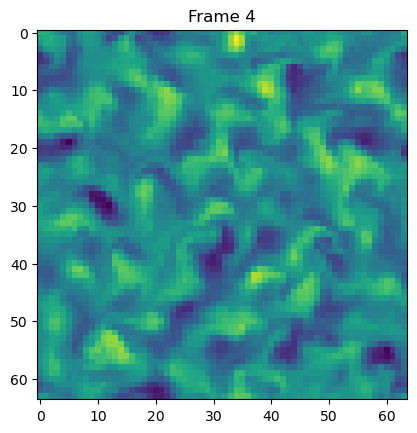

In [18]:
import h5py
from viz import animation 
from IPython.display import HTML

chan = 0
images = [pred[0,chan,:,:,i] for i in range(pred.shape[-1])]

ani = animation(images)
HTML(ani.to_jshtml())  # Or use ani.to_html5_video() for better quality